In [8]:
%cd /home/maia-user/NeuroCBIR/

/home/maia-user/NeuroCBIR


**FIGURE: EXAMPLE OF RESULT - GT FOR WHOLE BRAIN**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"


In [ ]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age', 'sex',
       'acq_date', 'raw', 'brain', 'seg'],
      dtype='object')


In [ ]:
retrival_res = pd.read_csv("data/results/whole_brain/eval_cl16/retrieval.csv")
retrival_res = retrival_res.rename(columns={"query": "GUID"})
metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")
metadata.tail()

METADATA: Original rows: 26685


,GUID,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,sex,acq_date,raw,brain,seg,top1,top2,top3,top4,top5
26680,miriad_257_5_MR_1,miriad,miriad_257,5,T1,1.5,GE MEDICAL SYSTEMS,Milwaukee WI,AD,68.20,F,NaN,MIRIAD/raw_data/dataset/miriad_257_AD_F/miriad...,MIRIAD/miriad/miriad_257_5_MR_1/mri/orig_nu_ma...,MIRIAD/miriad/miriad_257_5_MR_1/mri/aparc.DKTa...,miriad_257_6_MR_1,miriad_257_2_MR_1,miriad_257_3_MR_1,miriad_257_1_MR_1,miriad_257_3_MR_2
26681,miriad_257_6_MR_1,miriad,miriad_257,6,T1,1.5,GE MEDICAL SYSTEMS,Milwaukee WI,AD,68.43,F,NaN,MIRIAD/raw_data/dataset/miriad_257_AD_F/miriad...,MIRIAD/miriad/miriad_257_6_MR_1/mri/orig_nu_ma...,MIRIAD/miriad/miriad_257_6_MR_1/mri/aparc.DKTa...,miriad_257_1_MR_1,miriad_257_6_MR_2,miriad_257_5_MR_1,miriad_257_1_MR_2,miriad_257_3_MR_2
26682,miriad_257_6_MR_2,miriad,miriad_257,6,T1,1.5,GE MEDICAL SYSTEMS,Milwaukee WI,AD,68.43,F,NaN,MIRIAD/raw_data/dataset/miriad_257_AD_F/miriad...,MIRIAD/miriad/miriad_257_6_MR_2/mri/orig_nu_ma...,MIRIAD/miriad/miriad_257_6_MR_2/mri/aparc.DKTa...,miriad_257_6_MR_1,miriad_257_1_MR_1,miriad_257_1_MR_2,miriad_257_9_MR_1,miriad_257_4_MR_1
26683,miriad_257_7_MR_1,miriad,miriad_257,7,T1,1.5,GE MEDICAL SYSTEMS,Milwaukee WI,AD,68.70,F,NaN,MIRIAD/raw_data/dataset/miriad_257_AD_F/miriad...,MIRIAD/miriad/miriad_257_7_MR_1/mri/orig_nu_ma...,MIRIAD/miriad/miriad_257_7_MR_1/mri/aparc.DKTa...,miriad_257_9_MR_1,miriad_257_3_MR_1,miriad_257_1_MR_2,miriad_257_5_MR_1,miriad_257_6_MR_1
26684,miriad_257_9_MR_1,miriad,miriad_257,9,T1,1.5,GE MEDICAL SYSTEMS,Milwaukee WI,AD,69.18,F,NaN,MIRIAD/raw_data/dataset/miriad_257_AD_F/miriad...,MIRIAD/miriad/miriad_257_9_MR_1/mri/orig_nu_ma...,MIRIAD/miriad/miriad_257_9_MR_1/mri/aparc.DKTa...,miriad_257_10_MR_1,miriad_257_4_MR_1,miriad_257_7_MR_1,miriad_257_1_MR_1,miriad_257_6_MR_1


In [29]:
metadata.query("project == 'oasis3'")


,GUID,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,sex,acq_date,raw,brain,seg,top1,top2,top3,top4,top5
20971,OAS30001_MR_d0129,oasis3,OAS30001,129,T1,3.0,SIEMENS,TrioTim,CN,65.5,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0129/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d2430,OAS30001_MR_d3132,OAS30001_MR_d3746,OAS30001_MR_d4467
20972,OAS30001_MR_d0757,oasis3,OAS30001,757,T1,3.0,SIEMENS,TrioTim,CN,67.3,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0757/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_apar...,OAS30001_MR_d0129,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d2430,OAS30001_MR_d3746
20973,OAS30001_MR_d2430,oasis3,OAS30001,2430,T1,3.0,SIEMENS,Biograph_mMR,CN,71.8,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d2430/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_apar...,OAS30001_MR_d3746,OAS30001_MR_d0129,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d0757
20974,OAS30001_MR_d3132,oasis3,OAS30001,3132,T1,3.0,SIEMENS,TrioTim,CN,73.8,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3132/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_apar...,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d0129,OAS30001_MR_d3746,OAS30001_MR_d2430
20975,OAS30001_MR_d3746,oasis3,OAS30001,3746,T1,3.0,SIEMENS,Biograph_mMR,CN,75.5,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3746/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_apar...,OAS30001_MR_d2430,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d0129,OAS30001_MR_d0757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23647,OAS31470_MR_d0007,oasis3,OAS31470,7,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,64.9,NaN,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_norm...,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_apar...,I445714,I445696,OAS30927_MR_d1180,OAS30616_MR_d0199,I453074
23648,OAS31471_MR_d0059,oasis3,OAS31471,59,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,65.5,NaN,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_norm...,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_apar...,OAS30603_MR_d2253,OAS30603_MR_d0811,OAS30449_MR_d0000,OAS30449_MR_d0620,I169743
23649,OAS31472_MR_d0045,oasis3,OAS31472,45,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,67.4,NaN,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_norm...,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_apar...,OAS30092_MR_d0636,OAS30092_MR_d3727,OAS30867_MR_d4407,OAS31311_MR_d0055,miriad_199_5_MR_1
23650,OAS31473_MR_d0136,oasis3,OAS31473,136,T1,3.0,SIEMENS,Biograph_mMR,CN,57.0,NaN,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_norm...,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_apar...,OAS30908_MR_d0617,2666f701-9ae2-4c29-92b4-0f98344bb619,OAS30908_MR_d3517,01de3b17-6b57-427d-9c3e-7af281c4f141,26b751b5-6a7f-4203-9820-842a79ccd279


(A) Query: OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(B) I445714 - aibl
(C) I445696 - aibl
(D) OAS30927_MR_d1180 - oasis3
(E) OAS30616_MR_d0199 - oasis3
(F) I453074 - aibl


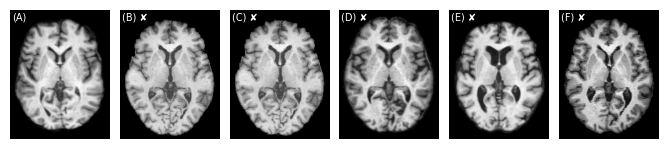

In [117]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_brain_slices(brains, titles, slice_index=None, axes=None):
    """Plot middle slice (or given slice) of each brain in a row."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[1] // 2  
        axes[i].imshow(brain[:, idx, : ].T, cmap="gray", origin="lower")
        # axes[i].set_title(title, y=0.9, x=0.35, va="top", color='w') #, fontsize=8)
        axes[i].axis("off")
        axes[i].text(0.02, 0.98, title, horizontalalignment='left', 
                     verticalalignment='top', transform=axes[i].transAxes, color='w')

        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(17*cm, 5*cm))

# Example usage:
query_guid = "OAS31470_MR_d0007"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [row["brain"]]
titles = ["(A)"]


title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append(match_row["brain"])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
brains = [load_nifti(p, DATA_PATH) for p in paths]

# Plot mid-slices
plot_brain_slices(brains, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()




(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d2430 - oasis3
(A.4) OAS30001_MR_d3132 - oasis3
(A.5) OAS30001_MR_d3746 - oasis3
(A.6) OAS30001_MR_d4467 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d0693 - oasis3
(B.3) OAS30052_MR_d2737 - oasis3
(B.4) OAS30052_MR_d2709 - oasis3
(B.5) OAS30052_MR_d4235 - oasis3
(B.6) OAS31193_MR_d0275 - oasis3
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) I445714 - aibl
(C.3) I445696 - aibl
(C.4) OAS30927_MR_d1180 - oasis3
(C.5) OAS30616_MR_d0199 - oasis3
(C.6) I453074 - aibl


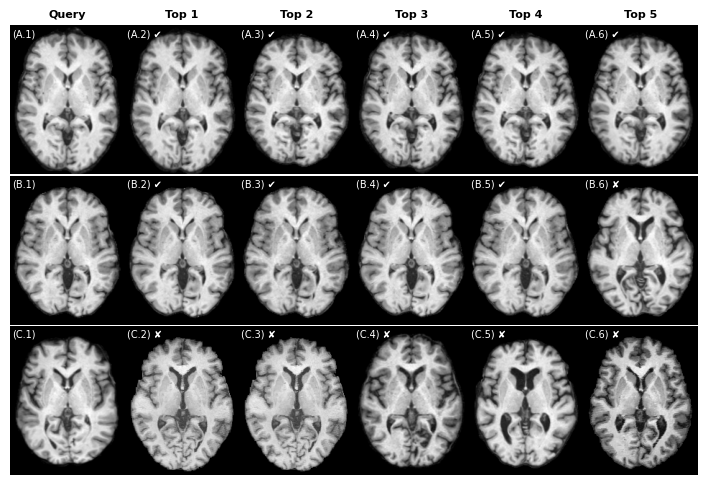

In [126]:
queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(18*cm, n_queries*4.1*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [row["brain"]]
    titles = [title_caps[0]]


    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append(match_row["brain"])
        titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

    # Load brain volumes
    brains = [load_nifti(p, DATA_PATH) for p in paths]

    # Plot mid-slices
    plot_brain_slices(brains, titles, axes=axes)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold", fontsize=8)
axess[0][1].set_title("Top 1", fontweight="bold", fontsize=8)
axess[0][2].set_title("Top 2", fontweight="bold", fontsize=8)
axess[0][3].set_title("Top 3", fontweight="bold", fontsize=8)
axess[0][4].set_title("Top 4", fontweight="bold", fontsize=8)
axess[0][5].set_title("Top 5", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=-0.001, hspace=0)

plt.savefig(f"figures/example_brain_retrieval.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
halt

**FIGURE: EXAMPLE OF RESULT - GT FOR BRAIN REGION**

In [240]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"


In [241]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age', 'sex',
       'acq_date', 'raw', 'brain', 'seg'],
      dtype='object')


In [242]:
retrival_res = pd.read_csv("data/results/region_brain/eval_cl32/retrieval_all.csv")
retrival_res = retrival_res.rename(columns={"query": "GUID"})
metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")
struct_name = "Right-Hippocampus"
metadata = metadata.query(f"LabelName == '{struct_name}'")
print(f"METADATA: after filering rows: {len(metadata)}")


METADATA: Original rows: 2857351
METADATA: after filering rows: 26176


In [243]:
metadata.query("project == 'oasis3'")

,GUID,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,...,acq_date,raw,brain,seg,top1,top2,top3,top4,top5,LabelName
2268107,OAS30001_MR_d0129,oasis3,OAS30001,129,T1,3.0,SIEMENS,TrioTim,CN,65.5,...,NaN,OASIS3/oasis3/OAS30001_MR_d0129/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268219,OAS30001_MR_d0757,oasis3,OAS30001,757,T1,3.0,SIEMENS,TrioTim,CN,67.3,...,NaN,OASIS3/oasis3/OAS30001_MR_d0757/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_apar...,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d0129,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268331,OAS30001_MR_d2430,oasis3,OAS30001,2430,T1,3.0,SIEMENS,Biograph_mMR,CN,71.8,...,NaN,OASIS3/oasis3/OAS30001_MR_d2430/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_apar...,OAS30001_MR_d3746,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d3132,OAS30001_MR_d0129,Right-Hippocampus
2268443,OAS30001_MR_d3132,oasis3,OAS30001,3132,T1,3.0,SIEMENS,TrioTim,CN,73.8,...,NaN,OASIS3/oasis3/OAS30001_MR_d3132/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3746,OAS30001_MR_d0129,OAS30001_MR_d2430,Right-Hippocampus
2268555,OAS30001_MR_d3746,oasis3,OAS30001,3746,T1,3.0,SIEMENS,Biograph_mMR,CN,75.5,...,NaN,OASIS3/oasis3/OAS30001_MR_d3746/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_norm...,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_apar...,OAS30001_MR_d2430,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d0129,Right-Hippocampus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2568667,OAS31470_MR_d0007,oasis3,OAS31470,7,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,64.9,...,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_norm...,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_apar...,slim_25762_2,slim_25794_1,slim_30980_1,slim_30883_1,slim_30828_1,Right-Hippocampus
2568779,OAS31471_MR_d0059,oasis3,OAS31471,59,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,65.5,...,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_norm...,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_apar...,2a24aaca-69ae-4dbc-9591-1eb6c7c531d9,610f4df2-e22f-4b2a-9849-5e466bdcc424,I472743,9a356541-1b93-49d2-9c1d-55fcf2ddd904,OAS31323_MR_d0123,Right-Hippocampus
2568892,OAS31472_MR_d0045,oasis3,OAS31472,45,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,67.4,...,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_norm...,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_apar...,slim_30753_3,slim_30753_1,OAS31016_MR_d0126,03195db1-70ec-4556-90d2-1477d7f7b764,0b5b00cd-4698-4670-90c9-7f79900aae40,Right-Hippocampus
2569005,OAS31473_MR_d0136,oasis3,OAS31473,136,T1,3.0,SIEMENS,Biograph_mMR,CN,57.0,...,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_norm...,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_apar...,OAS30595_MR_d0848,OAS30595_MR_d0084,OAS31311_MR_d0055,558d6564-0369-4450-9d7e-96dfd19b6640,3a1cb653-0fa4-42c0-916b-92d06a435190,Right-Hippocampus


In [244]:
# Load labels and bounding boxes for cortical/subcortical structures
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

(A) Query: OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(B) OAS30001_MR_d0757 - oasis3
(C) OAS30001_MR_d4467 - oasis3
(D) OAS30001_MR_d3132 - oasis3
(E) OAS30001_MR_d2430 - oasis3
(F) OAS30001_MR_d3746 - oasis3


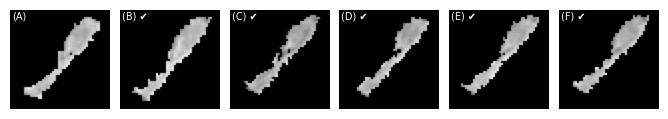

In [245]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_struct_slices(brains, titles, slice_index=None, axes=None):
    """Plot middle slice (or given slice) of each brain in a row."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[0] // 2  
        axes[i].imshow(brain[idx, :, : ].T, cmap="gray", origin="lower")
        # axes[i].set_title(title, y=0.9, x=0.35, va="top", color='w') #, fontsize=8)
        axes[i].axis("off")
        axes[i].text(0.02, 0.98, title, horizontalalignment='left', 
                     verticalalignment='top', transform=axes[i].transAxes, color='w')
        
def obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df):
    image = load_nifti(brain_path, DATA_PATH).astype(np.float32)
    seg = load_nifti(seg_path, DATA_PATH)

    # Filter the label row for the selected structure
    struct_row_df = labels_bb_df.query(f"LabelName == '{target_struct_name}' and Use == 1").reset_index(drop=True)
    if len(struct_row_df) == 0:
        raise ValueError(f"Structure '{target_struct_name}' not found in labels_bb_df with Use == 1.")
    struct_row = struct_row_df.iloc[0]
    struct_map_id = struct_row["LabelID"]

    # Bounding box
    x1, x2 = int(struct_row["min_x"]) - 5, int(struct_row["max_x"]) + 5
    y1, y2 = int(struct_row["min_y"]) - 5, int(struct_row["max_y"]) + 5
    z1, z2 = int(struct_row["min_z"]) - 5, int(struct_row["max_z"]) + 5

    # Preprocess all samples
    patch_brain = image[x1:x2, y1:y2, z1:z2]
    patch_seg = (seg[x1:x2, y1:y2, z1:z2] == struct_map_id)

    struct = patch_brain * patch_seg
    
    return struct

        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(17*cm, 5*cm))

# Example usage:
query_guid = "OAS30001_MR_d0129"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [[row["brain"], row["seg"]]]
titles = ["(A)"]

title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append([match_row["brain"], match_row["seg"]])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

# Plot mid-slices
plot_struct_slices(structs, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()

(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d4467 - oasis3
(A.4) OAS30001_MR_d3132 - oasis3
(A.5) OAS30001_MR_d2430 - oasis3
(A.6) OAS30001_MR_d3746 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d2709 - oasis3
(B.3) OAS30052_MR_d2737 - oasis3
(B.4) OAS30052_MR_d0693 - oasis3
(B.5) OAS30052_MR_d4235 - oasis3
(B.6) OAS30284_MR_d1633 - oasis3
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) slim_25762_2 - slim
(C.3) slim_25794_1 - slim
(C.4) slim_30980_1 - slim
(C.5) slim_30883_1 - slim
(C.6) slim_30828_1 - slim


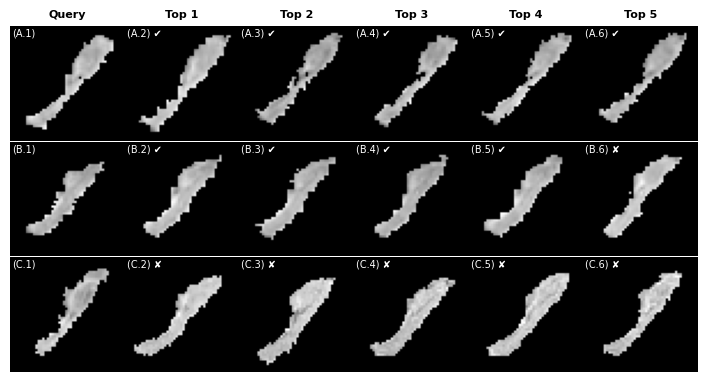

In [248]:
queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(18*cm, n_queries*3.22*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [[row["brain"], row["seg"]]]
    titles = [title_caps[0]]


    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append([match_row["brain"], match_row["seg"]])
        titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

    # Load brain volumes
    structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

    # Plot mid-slices
    plot_struct_slices(structs, titles, axes=axes)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold", fontsize=8)
axess[0][1].set_title("Top 1", fontweight="bold", fontsize=8)
axess[0][2].set_title("Top 2", fontweight="bold", fontsize=8)
axess[0][3].set_title("Top 3", fontweight="bold", fontsize=8)
axess[0][4].set_title("Top 4", fontweight="bold", fontsize=8)
axess[0][5].set_title("Top 5", fontweight="bold", fontsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=-0.001, hspace=0)

plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', bbox_inches='tight')
plt.show()